# 04 — Old Dataset Model Training

This notebook trains the model for the cleaned old sensor dataset.

## Modeling choice

The dataset contains only **7 `BROKEN` rows**, so a normal supervised 3-class classifier would be unstable and would not provide a reliable failure model.

Instead, this notebook trains an **Isolation Forest anomaly detector** using `NORMAL` operating data.

The model produces:
- `anomaly_score`
- `anomaly_flag`
- calibration threshold

The original `machine_status` labels are used for evaluation only.

This model is intended to complement the newer predictive-maintenance model:

`old sensor anomaly model → anomaly_score / machine condition`

rather than replacing the newer failure prediction model.


In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

pd.set_option("display.max_columns", 120)

BASE_DIR = Path("..")
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"

INPUT_FILE = PROCESSED_DATA_DIR / "sensor_features.csv"
MODEL_FILE = MODELS_DIR / "old_sensor_anomaly_model.joblib"
METADATA_FILE = MODELS_DIR / "old_sensor_anomaly_metadata.json"

RANDOM_STATE = 42
NORMAL_TRAIN_FRACTION = 0.80
N_ESTIMATORS = 300
CONTAMINATION = 0.01

print("Input:", INPUT_FILE)
print("Model:", MODEL_FILE)
print("Metadata:", METADATA_FILE)


Input: ..\data\processed\sensor_features.csv
Model: ..\models\old_sensor_anomaly_model.joblib
Metadata: ..\models\old_sensor_anomaly_metadata.json


In [2]:
df = pd.read_csv(INPUT_FILE, parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print("Shape:", df.shape)
print("\nStatus distribution:")
print(df["machine_status"].value_counts())


Shape: (220320, 40)

Status distribution:
machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64


## 1. Define model features

`timestamp` and `machine_status` are not used as model inputs.

All other numeric engineered features are used. Missing values are handled inside the pipeline.


In [3]:
feature_columns = [
    c for c in df.columns
    if c not in ["timestamp", "machine_status"]
]

X_all = df[feature_columns].replace([np.inf, -np.inf], np.nan)
normal_mask = df["machine_status"].eq("NORMAL")

print("Feature count:", len(feature_columns))
print("Normal rows:", int(normal_mask.sum()))
print("Non-normal rows:", int((~normal_mask).sum()))


Feature count: 38
Normal rows: 205836
Non-normal rows: 14484


## 2. Temporal training set

Only `NORMAL` observations are used to fit the anomaly detector.

To reduce contamination from abnormal periods, the first 80% of the normal observations in time order are used for training. The remaining normal observations are reserved for evaluation.

All `RECOVERING` and `BROKEN` rows are kept outside model fitting and are used as abnormal evaluation examples.


In [4]:
normal_indices = df.index[normal_mask]
split_position = int(len(normal_indices) * NORMAL_TRAIN_FRACTION)

train_normal_idx = normal_indices[:split_position]
eval_normal_idx = normal_indices[split_position:]

train_normal = X_all.loc[train_normal_idx]

# Evaluation set:
# - held-out NORMAL rows
# - all RECOVERING/BROKEN rows
eval_indices = eval_normal_idx.union(df.index[~normal_mask])
X_eval = X_all.loc[eval_indices]

# Binary evaluation label:
# NORMAL = 0
# RECOVERING/BROKEN = 1
y_eval = (~df.loc[eval_indices, "machine_status"].eq("NORMAL")).astype(int)

print("Training NORMAL rows:", len(train_normal))
print("Evaluation rows:", len(X_eval))
print("Evaluation abnormal rows:", int(y_eval.sum()))
print("Evaluation normal rows:", int((y_eval == 0).sum()))


Training NORMAL rows: 164668
Evaluation rows: 55652
Evaluation abnormal rows: 14484
Evaluation normal rows: 41168


## 3. Train Isolation Forest

The pipeline contains:
1. Median imputation
2. Standardization
3. Isolation Forest

The complete pipeline is saved as one `.joblib` file so the same preprocessing is used during inference.


In [5]:
model_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            IsolationForest(
                n_estimators=N_ESTIMATORS,
                contamination=CONTAMINATION,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

model_pipeline.fit(train_normal)

print("Model training completed.")


Model training completed.


## 4. Convert Isolation Forest output to an anomaly score

`decision_function()` is higher for normal observations.

We invert it so that:

- higher `anomaly_score` = more anomalous
- lower `anomaly_score` = more normal

The score is calibrated to the training-normal distribution and clipped to `[0, 1]`.


In [6]:
def raw_anomaly_score(pipeline, X):
    # Isolation Forest decision function:
    # higher = more normal, so invert it.
    return -pipeline.decision_function(X)

train_raw_scores = raw_anomaly_score(model_pipeline, train_normal)

# Robust calibration based only on NORMAL training data.
score_low = float(np.percentile(train_raw_scores, 5))
score_high = float(np.percentile(train_raw_scores, 95))

if score_high <= score_low:
    score_high = score_low + 1e-9

def calibrate_score(raw_scores):
    return np.clip(
        (raw_scores - score_low) / (score_high - score_low),
        0,
        1,
    )

# Threshold at the 95th percentile of normal training anomaly scores.
ANOMALY_THRESHOLD = float(np.percentile(train_raw_scores, 95))

print("Raw score calibration low :", score_low)
print("Raw score calibration high:", score_high)
print("Anomaly threshold        :", ANOMALY_THRESHOLD)


Raw score calibration low : -0.23806064172560862
Raw score calibration high: -0.05081508432158591
Anomaly threshold        : -0.05081508432158591


In [7]:
eval_raw_scores = raw_anomaly_score(model_pipeline, X_eval)
eval_scores = calibrate_score(eval_raw_scores)

# For the binary evaluation only, flag observations whose raw anomaly
# score exceeds the threshold learned from normal training data.
y_pred = (eval_raw_scores >= ANOMALY_THRESHOLD).astype(int)

print("ROC-AUC:", roc_auc_score(y_eval, eval_raw_scores))
print("PR-AUC :", average_precision_score(y_eval, eval_raw_scores))

print("\nConfusion matrix:")
print(confusion_matrix(y_eval, y_pred))

print("\nClassification report:")
print(
    classification_report(
        y_eval,
        y_pred,
        target_names=["NORMAL", "RECOVERING/BROKEN"],
        zero_division=0,
    )
)


ROC-AUC: 0.730474695639602
PR-AUC : 0.4423897662765244

Confusion matrix:
[[40313   855]
 [13907   577]]

Classification report:
                   precision    recall  f1-score   support

           NORMAL       0.74      0.98      0.85     41168
RECOVERING/BROKEN       0.40      0.04      0.07     14484

         accuracy                           0.73     55652
        macro avg       0.57      0.51      0.46     55652
     weighted avg       0.65      0.73      0.64     55652



In [8]:
evaluation_output = df.loc[eval_indices, ["timestamp", "machine_status"]].copy()
evaluation_output["anomaly_score"] = eval_scores
evaluation_output["anomaly_flag"] = y_pred

print("Mean anomaly score by machine status:")
display(
    evaluation_output
    .groupby("machine_status")["anomaly_score"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)


Mean anomaly score by machine status:


,count,mean,median,max
machine_status,,,,
RECOVERING,14477,0.398143,0.345577,1.0
BROKEN,7,0.299070,0.205026,1.0
NORMAL,41168,0.263288,0.237266,1.0


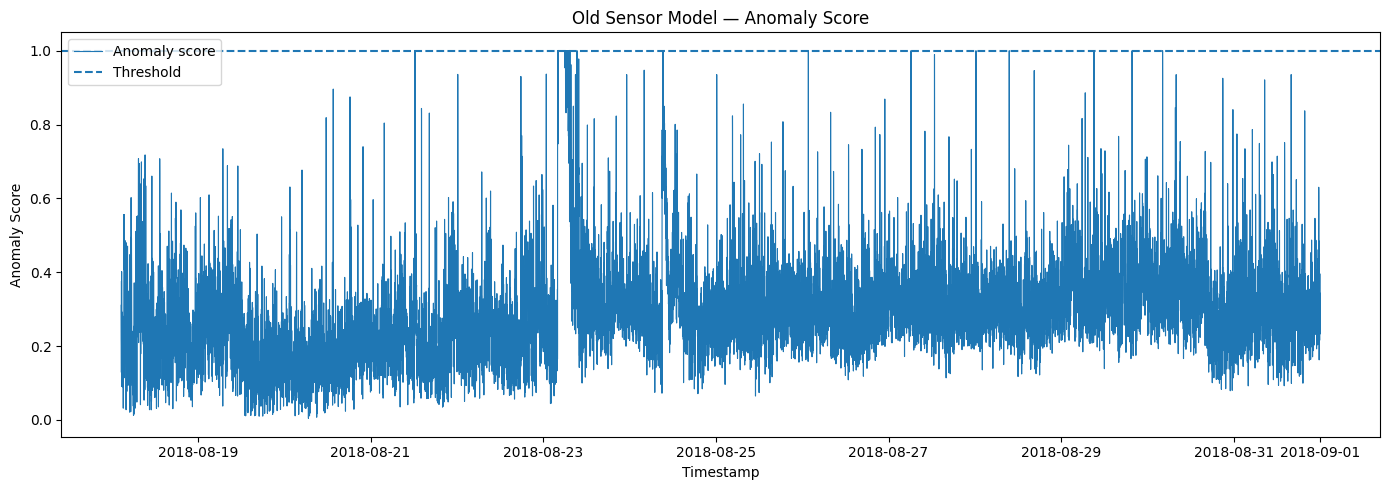

In [9]:
# Visualize a short evaluation window.
plot_df = evaluation_output.sort_values("timestamp").tail(20000)

plt.figure(figsize=(14, 5))
plt.plot(
    plot_df["timestamp"],
    plot_df["anomaly_score"],
    linewidth=0.8,
    label="Anomaly score",
)
plt.axhline(
    calibrate_score(np.array([ANOMALY_THRESHOLD]))[0],
    linestyle="--",
    label="Threshold",
)
plt.title("Old Sensor Model — Anomaly Score")
plt.xlabel("Timestamp")
plt.ylabel("Anomaly Score")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Save the model and metadata

The metadata file stores:
- feature order
- selected sensors/features
- threshold
- calibration values
- training configuration
- model purpose

This will make backend integration easier later.


In [10]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(model_pipeline, MODEL_FILE)

metadata = {
    "model_type": "IsolationForest",
    "model_purpose": "sensor_anomaly_detection",
    "random_state": RANDOM_STATE,
    "n_estimators": N_ESTIMATORS,
    "contamination": CONTAMINATION,
    "normal_train_fraction": NORMAL_TRAIN_FRACTION,
    "feature_columns": feature_columns,
    "anomaly_threshold_raw": ANOMALY_THRESHOLD,
    "score_calibration_low": score_low,
    "score_calibration_high": score_high,
    "training_rows": int(len(train_normal)),
    "dataset_rows": int(len(df)),
    "status_classes_in_dataset": sorted(df["machine_status"].dropna().unique().tolist()),
    "note": (
        "The model is trained only on NORMAL observations. "
        "RECOVERING and BROKEN labels are used for evaluation, not training. "
        "The dataset contains only 7 BROKEN rows, so this is an anomaly model "
        "rather than a conventional BROKEN classifier."
    ),
}

with open(METADATA_FILE, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved model   :", MODEL_FILE)
print("Saved metadata:", METADATA_FILE)


Saved model   : ..\models\old_sensor_anomaly_model.joblib
Saved metadata: ..\models\old_sensor_anomaly_metadata.json


## 6. Reload test

This verifies that the saved model can be loaded independently and can produce an anomaly score from the same feature structure.


In [11]:
loaded_model = joblib.load(MODEL_FILE)

sample = X_all.iloc[[0]]
sample_raw = raw_anomaly_score(loaded_model, sample)
sample_score = calibrate_score(sample_raw)[0]

print("Sample timestamp:", df.loc[sample.index[0], "timestamp"])
print("Sample status   :", df.loc[sample.index[0], "machine_status"])
print("Anomaly score   :", float(sample_score))
print("Model reload test: PASSED")


Sample timestamp: 2018-04-01 00:00:00
Sample status   : NORMAL
Anomaly score   : 0.039302137598998366
Model reload test: PASSED
